In [1]:
import os
import sys
import glob

import numpy as np
from cora.util import units

from draco.util import tools
from fitstack import containers

In [2]:
import getdist
from getdist import plots, MCSamples

Matplotlib created a temporary cache directory at /tmp/matplotlib-h_4mbgf0 because the default path (/home/h/halpern/arnab92/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib inline

In [4]:
from fitstack.chaintools import extract_priors, gdchain

In [5]:
from draco.core.containers import FrequencyStack, FrequencyStackByPol, MockFrequencyStack, FormedBeam
from fitstack.containers import MCMCFit1D, MCMCFitPowerSpectrum1D

In [6]:
cyl = 'allcyl'
pol_sel_iq = 'iq'
window = 'uniform'
reg = 'flat'
taper = 'v2'
cutabs = 7
cut = 10
band='full'
with_shot = False
with_scaled_noise = True

In [7]:
path_fit = f"/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/cyl_{cyl}/all_time_mask_only/pol{pol_sel_iq}/band{band}_{window}_absorb_nearby_nsig_{cutabs}_{reg}/{cut}Jy_base_{taper}/"

In [8]:
path_fit

'/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/cyl_allcyl/all_time_mask_only/poliq/bandfull_uniform_absorb_nearby_nsig_7_flat/10Jy_base_v2/'

In [9]:
path_data = f"/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/cyl_{cyl}/all_time_mask_only/pol{pol_sel_iq}/band{band}_{window}_absorb_nearby_nsig_{cutabs}_{reg}/{cut}Jy_base_{taper}"
print(path_data)
ps1d_data = containers.PowerSpectrum1D.from_file(os.path.join(path_data,"pspec_1d_all_bandb.h5"))

/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/cyl_allcyl/all_time_mask_only/poliq/bandfull_uniform_absorb_nearby_nsig_7_flat/10Jy_base_v2


In [10]:
redshift = ps1d_data.attrs['redshift']

In [11]:
alphaFoG_power=[0.0,-1.0]
alphaFoG_min=0.1
alphaFoG_max=[5.0,10.0,20.0]
nsample=500000
nwalker=32

In [12]:
latex_names = {
    "omega": r"\Omega_{\rm HI}",
    "b_HI": r"b_{\rm HI}",
    "NL": r"\alpha_{\rm NL}",
    "FoGh": r"\alpha_{\rm FoG,HI}",
    "SN": r"SN",
    "FoGs": r"\alpha_{\rm FoG,s}",
}

In [13]:
for ii, alpha_p in enumerate(alphaFoG_power):
    for jj, alpha_max in enumerate(alphaFoG_max):
        choise_param = f"4para_Ombsampling_pow{alpha_p}_FoGmin{alphaFoG_min}_FoGmax{alpha_max}_nsamp{nwalker}x{nsample}"
        data = os.path.join(path_fit,choise_param,"mcmc_fit_1D_ps.h5")
        fit_1D = MCMCFitPowerSpectrum1D.from_file(data)
        
        # Extract the prior ranges from a MCMC fit chain 
        ranges = extract_priors(fit_1D)
        print(ranges)
        
        # Convert a CHIME MCMCFit object into something getdist can understand
        chain = gdchain(fit_1D, latex_names=latex_names, thin=20, ignore_rows=0.1, ranges=ranges)
        save_path = "/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/chains/"
        outname = save_path + f"chain_autops_pow{alpha_p}_FoGmin{alphaFoG_min}_FoGmax{alpha_max}.gdchain"
        # chain.savePickle(str(outname))

{'omega': (0.0, 20.0), 'b_HI': (0.0, 10), 'NL': (0.0, 5)}
Removed 0.1 as burn in
{'omega': (0.0, 20.0), 'b_HI': (0.0, 10), 'NL': (0.0, 5)}
Removed 0.1 as burn in
{'omega': (0.0, 20.0), 'b_HI': (0.0, 10), 'NL': (0.0, 5)}
Removed 0.1 as burn in
{'omega': (0.0, 20.0), 'b_HI': (0.0, 10), 'NL': (0.0, 5)}
Removed 0.1 as burn in
{'omega': (0.0, 20.0), 'b_HI': (0.0, 10), 'NL': (0.0, 5)}
Removed 0.1 as burn in
{'omega': (0.0, 20.0), 'b_HI': (0.0, 10), 'NL': (0.0, 5)}
Removed 0.1 as burn in


<Figure size 1000x1000 with 0 Axes>

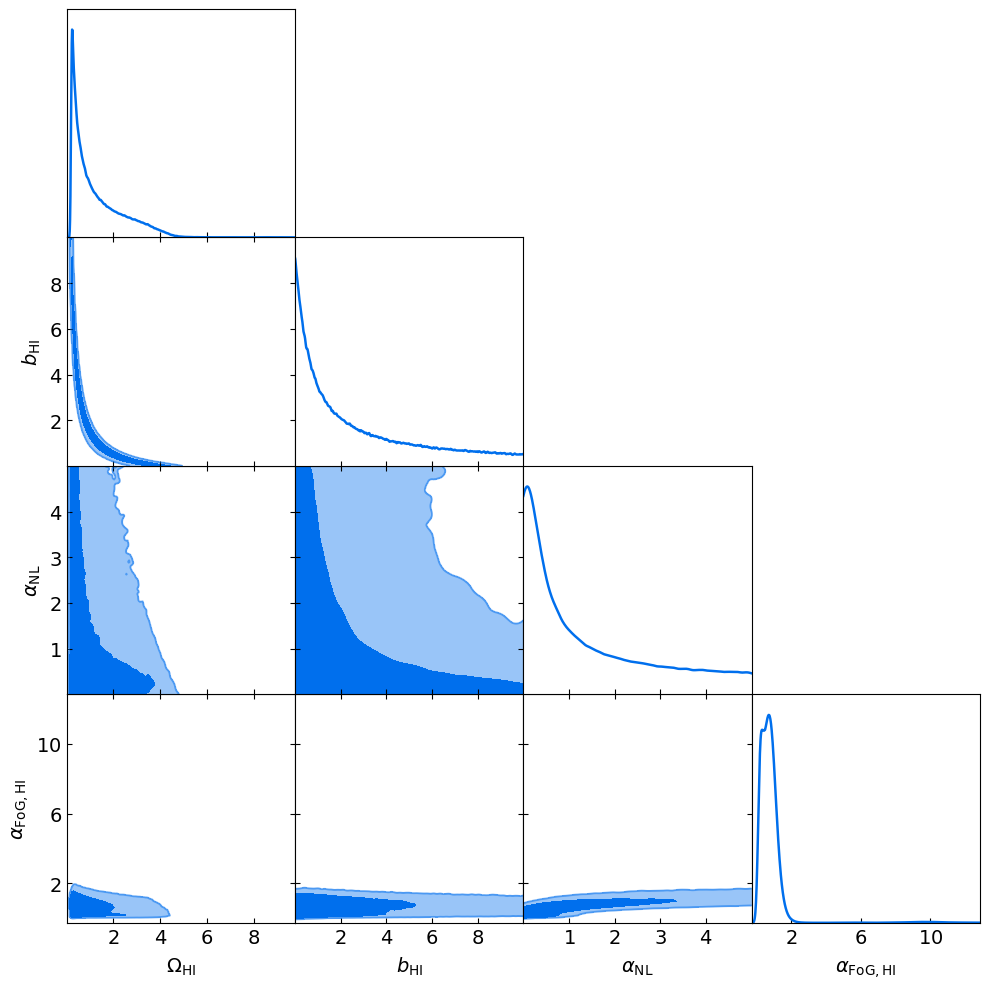

In [14]:
# Create plotter with larger size and better settings
g = plots.get_single_plotter(
    width_inch=10,           # Larger width for better readability
    scaling=True,
    ratio=1                  # Square aspect ratio
)

# Set additional GetDist-specific settings for publication quality
g.settings.axes_fontsize = 16        # Axis label font size
g.settings.lab_fontsize = 16         # Parameter label font size  
g.settings.legend_fontsize = 16      # Legend font size
#g.settings.colorbar_label_fontsize = 14
g.settings.title_limit_fontsize = 16

# Optional: Customize line widths and contour properties
g.settings.linewidth = 2.5           # Contour line width
g.settings.linewidth_contour = 2.0   # Filled contour edge width
g.settings.alpha_filled_add = 0.85   # Filled contour transparency

g.triangle_plot(
        [chain],
        
        filled=True,
        legend_loc=(0.6, 0.8),
        )